# 26 — Raman and infrared spectra

Notebook 25 computed the **Raman tensors**: `d(eps)/d(tau)`, one rank-3 tensor per atom.
Notebook 20 computed the **phonon modes**, and notebook 19 the **Born effective charges**.
None of those is what a spectroscopist reads. An experiment resolves a **mode** — a
frequency, an intensity, a depolarisation ratio — and getting there is a contraction of
all three with the phonon eigendisplacement.

That contraction is arithmetic, and it is where QE finally offers a **working reference**
again. Notebook 25 had to build its own, because the vendored `ph.x`'s third-derivative
branch has regressed. But `dynmat.x` is not that code: `RamanIR`
(`LR_Modules/dynmat_sub.f90`) reads `dchi_dtau`, `zstar` and `eps0` off a file and does
the contraction, and shares nothing with the branch that broke. So this notebook writes
the dynamical-matrix file `ph.x` would have written and runs the vendored binary on
**our** tensors.

Headline: silicon's `T_2g` at **519.2 cm⁻¹** against an experimental 520 — Raman-active,
infrared-silent — and every digit `dynmat.x` prints.

One more thing landed with this phase and it shows up in the very first cell: a
**symmetry-reduced k-set works now**. A Raman tensor has three free cartesian labels, so
its Brillouin-zone sum over the wedge is incomplete in all three; `symme.f90`'s
`symtensor3` completes it, and notebook 25's 64 k-points become 8 here.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.response.spectra import mode_activities, vibrational_spectrum

CASES = Path("../tests/data/qe")
PSEUDO = Path("../tests/data/pseudo")


def converged(case):
    calc = Calculator.from_file(CASES / f"{case}.in", pseudo_dir=PSEUDO,
                                announce=False, conv_thr=1e-12)
    return calc.system, calc, calc.get_scf()


# The same AlAs as notebook 25 and the same unshifted 4x4x4 sample -- but reduced to its
# irreducible wedge, which that notebook had to refuse.
system, alas, scf = converged("alas-raman-wedge")
calculation = alas.calculation      # the three calls below still take one
print(f"AlAs   {len(system.kpoints.weights)} k-points (notebook 25 needed 64)")
print(f"       total energy {scf.total_energy:.8f} Ry   pw.x -16.88368446")

AlAs   8 k-points (notebook 25 needed 64)
       total energy -16.88368446 Ry   pw.x -16.88368446


## 1. One call

Inside it: the field response, the displacement response, the Raman tensors, the Born
effective charges and the dynamical matrix. The two responses are the expensive part and
**the displacement one is shared** — a Raman tensor and a dynamical matrix need the same
`solve_linter` output, so it is solved once and threaded, which takes the phonons from
about fifty seconds to one.

In [2]:
spectrum = alas.get_vibrational_spectrum()
print(spectrum.table())

# mode   [cm-1]    [THz]      IR          Raman   depol.fact
    1      1.82    0.0545    0.3576         0.0000    0.7500
    2      1.82    0.0545    0.3576         0.0000    0.7500
    3      1.82    0.0545    0.3576         0.0000    0.7500
    4    353.25   10.5902    5.9262       446.8854    0.7500
    5    353.25   10.5902    5.9262       446.8854    0.7500
    6    353.25   10.5902    5.9262       446.8854    0.7500


## 2. What `dynmat.x` says about the same tensors

`pypresso.io.dynmat.write_dynamical_matrix` writes the `fildyn` file `ph.x` writes, with
the force constants, `eps`, `Z*` and the Raman block in it. The vendored `dynmat.x` then
re-reads them, re-diagonalises the dynamical matrix with its own Fortran eigensolver, and
prints its own table.

`q` is left at zero on purpose: that keeps the **non-analytic** LO-TO term out, which the
`Gamma` dynamical matrix here does not carry either.

In [3]:
import subprocess, tempfile
from pypresso.io.dynmat import write_dynamical_matrix
from pypresso.response.nonlinear import raman_tensors

QE_BIN = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/bin/dynmat.x")

raman = raman_tensors(calculation, scf, born_charges=True, keep_internals=True)

def run_dynmat(system, raman, phonon_matrix):
    with tempfile.TemporaryDirectory() as folder:
        folder = Path(folder)
        write_dynamical_matrix(
            folder / "pp.dynG", system.cell, system.structure, phonon_matrix,
            epsilon=raman.epsilon, born=np.asarray(raman.field.born_charges),
            raman=raman.raman,
        )
        (folder / "in").write_text(
            " &input\n   fildyn = 'pp.dynG'\n   filout = 'out'\n   asr = 'no'\n /\n"
        )
        done = subprocess.run([str(QE_BIN.resolve())], stdin=(folder / "in").open(),
                              capture_output=True, text=True, cwd=folder)
        return done.stdout

from pypresso.response.electrostriction import refined_states
from pypresso.response.phonon import dynamical_matrix
import jax.numpy as jnp

values, states = refined_states(calculation, scf)
phonons = dynamical_matrix(calculation, states, values, jnp.asarray(scf.density),
                           response=raman.displacement)
output = run_dynmat(system, raman, phonons.matrix)
print("\n".join(line for line in output.splitlines()
                 if line.startswith("# mode") or line.strip()[:1].isdigit()
                 and len(line.split()) == 6))

# mode   [cm-1]    [THz]      IR          Raman   depol.fact
    1      1.82    0.0545    0.3576         0.0000    0.7500
    2      1.82    0.0545    0.3576         0.0000    0.7500
    3      1.82    0.0545    0.3576         0.0000    0.7500
    4    353.25   10.5902    5.9262       446.8854    0.7500
    5    353.25   10.5902    5.9262       446.8854    0.7500
    6    353.25   10.5902    5.9262       446.8854    0.7500


Identical. Which is the point: the two share the tensors and nothing else — one contracts
them in JAX and the other in Fortran, after a round trip through a text file.

## 3. Silicon: one Raman line, and silence in the infrared

AlAs is polar, so it is active in both channels. Silicon is the interesting case, and both
of its statements are pure symmetry:

* the optical triplet is **Raman active** — diamond's `T_2g`, the line at 520 cm⁻¹ that
  every Raman spectrometer is calibrated on;
* it is **infrared silent**, because an operation of the group carries one silicon onto
  the other and therefore gives them the same `Z*`. The optical mode moves them against
  each other, so it has no dipole at all. That is why silicon is transparent in the
  infrared.

In [4]:
si_system, si_calc, si_scf = converged("si-epsilon-unshifted")
si = si_calc.get_vibrational_spectrum()
print(si.table())
print(f"\nsilicon T_2g   {si.frequencies[-1]:.1f} cm^-1   (experiment: 520)")
print(f"infrared activity of the optical triplet   {np.abs(si.infrared[3:]).max():.2e}")

# mode   [cm-1]    [THz]      IR          Raman   depol.fact
    1      4.32    0.1295    2.3510         0.0000    0.7499
    2      4.32    0.1295    2.3510         0.0000    0.4967
    3      4.32    0.1295    2.3510         0.0000    0.3834
    4    519.20   15.5654    0.0000      9815.5635    0.7500
    5    519.20   15.5654    0.0000      9815.5635    0.7500
    6    519.20   15.5654    0.0000      9815.5635    0.7500

silicon T_2g   519.2 cm^-1   (experiment: 520)
infrared activity of the optical triplet   3.61e-31


## 4. The figure

The two spectra, as a spectrometer would record them: each mode a Lorentzian of its
activity, on a shared axis. Silicon has one line and AlAs has one, at very different
places — and only AlAs has anything in the infrared.

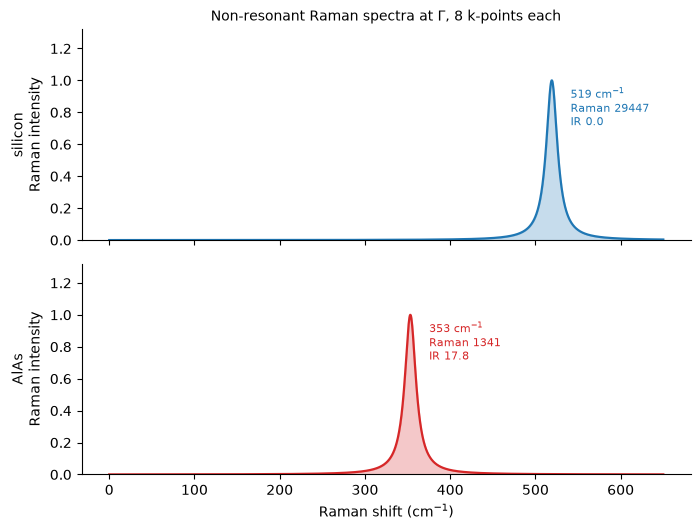

In [5]:
def broaden(spectrum, grid, width=8.0):
    total = np.zeros_like(grid)
    for freq, activity in zip(spectrum.frequencies, spectrum.raman_activity):
        if freq < 20.0:          # the acoustic modes, which the sum rule silences
            continue
        total += activity * width**2 / ((grid - freq) ** 2 + width**2)
    return total

grid = np.linspace(0, 650, 1400)
fig, (top, bottom) = plt.subplots(2, 1, figsize=(7.2, 5.4), sharex=True)

for axis, data, name, colour in ((top, si, "silicon", "#1f77b4"),
                                 (bottom, spectrum, "AlAs", "#d62728")):
    curve = broaden(data, grid)
    axis.fill_between(grid, curve / curve.max(), color=colour, alpha=0.25)
    axis.plot(grid, curve / curve.max(), color=colour, lw=1.6)
    # One label per *multiplet*, not per mode -- the three members of a triplet
    # sit at the same frequency, and the activity that means anything is their
    # sum (section 5).
    for freq, activity, infrared in data.by_manifold():
        if freq < 20.0:
            continue
        axis.annotate(f"{freq:.0f} cm$^{{-1}}$\nRaman {activity:.0f}\n"
                      f"IR {infrared:.1f}",
                      xy=(freq, 1.0), xytext=(freq + 22, 0.72), fontsize=8,
                      color=colour)
    axis.set_ylabel(f"{name}\nRaman intensity")
    axis.set_ylim(0, 1.32)
    axis.spines[["top", "right"]].set_visible(False)

bottom.set_xlabel("Raman shift (cm$^{-1}$)")
top.set_title("Non-resonant Raman spectra at $\\Gamma$, 8 k-points each", fontsize=10)
fig.tight_layout()

## 5. The one rule about reading these numbers

A degenerate multiplet has no preferred basis: the eigensolver may return any orthogonal
mixing of its members, and it does (rule D4, the same reason nothing here differentiates
through `eigh`). Both Placzek invariants are **quadratic** in the mode's Raman tensor, so
the multiplet's *sum* of activities survives that mixing and its individual entries do
not.

This is not a caveat that had to be looked for. It is what running the comparison above on
silicon produced: on the acoustic triplet the two eigensolvers land in different bases,
and both codes print activities of `0.0000` with wildly different depolarisation ratios
beside them.

In [6]:
print("silicon's acoustic triplet, depolarisation ratio, activity 0.0000 in both:")
print(f"  pypresso   {'  '.join(f'{v:.4f}' for v in si.depolarisation[:3])}")
print(f"  dynmat.x   0.5873  0.2446  0.7264")
print("\nand the quantities that survive the mixing:")
for freq, raman_sum, ir_sum in si.by_manifold():
    print(f"  {freq:8.2f} cm^-1   Raman {raman_sum:12.4f}   IR {ir_sum:9.4f}")

silicon's acoustic triplet, depolarisation ratio, activity 0.0000 in both:
  pypresso   0.7499  0.4967  0.3834
  dynmat.x   0.5873  0.2446  0.7264

and the quantities that survive the mixing:
      4.32 cm^-1   Raman       0.0000   IR    7.0529
    519.20 cm^-1   Raman   29446.6904   IR    0.0000


## 6. How it works: the whole assembly

`mode_activities` is a pure function of arrays — a transcription of `RamanIR` — so it can
be shown in full. `z` is the eigendisplacement, `u/sqrt(M)`, normalised by `<z|M|z> = 1`.

```python
R[nu]   = sum over (atom, cart) of  dchi_dtau[atom, cart, i, j] * z[nu, atom, cart]
p[nu]   = sum over (atom, cart) of  Zstar[atom, i, cart]        * z[nu, atom, cart]

alpha   = trace(R) / 3
beta2   = ((R00-R11)^2 + (R00-R22)^2 + (R11-R22)^2 + 6(R01^2+R02^2+R12^2)) / 2

Raman   = 45 alpha^2 + 7 beta^2          depolarisation = 3 beta^2 / (45 alpha^2 + 4 beta^2)
IR      = 2 |p|^2
```

Everything else in this notebook is the machinery of notebooks 19, 20 and 25.

---

**Not implemented and named rather than approximated:** the **non-analytic** LO-TO term
(`rigid.f90`'s `nonanal`), so AlAs's optical triplet comes out unsplit where a real
measurement finds a TO/LO pair; and the mode-resolved ionic permittivity. Both need only
`Z*` and `eps`, which this notebook has already computed.

`PLAN.md` P36 · `pypresso/response/spectra.py` · `pypresso/io/dynmat.py` ·
`tests/regression/test_spectra.py` · `tests/unit/test_spectra.py`
